In [1]:
#Downloads the plastic pollution dataset to the environment
!curl -L -o plastic-pollution.zip\
  https://www.kaggle.com/api/v1/datasets/download/imtkaggleteam/plastic-pollution

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 11229  100 11229    0     0  16270      0 --:--:-- --:--:-- --:--:-- 16270


In [2]:
#downloads the population dataset to the environment
!curl -L -o world-population-growth.zip\
  https://www.kaggle.com/api/v1/datasets/download/maheshmani13/world-population-growth

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  1621  100  1621    0     0   3708      0 --:--:-- --:--:-- --:--:--  3708


In [3]:
#confirm that the zips exist in the data
!unzip -l plastic-pollution.zip
!unzip -l world-population-growth.zip

Archive:  plastic-pollution.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
     2086  11-03-2023 07:09   1- global-plastics-production.csv
     4973  11-03-2023 07:09   2- share-of-global-plastic-waste-emitted-to-the-ocean.csv
    12183  11-03-2023 07:09   3- share-plastic-fate.csv
     5076  11-03-2023 07:09   4- mismanaged-plastic-waste-per-capita.csv
---------                     -------
    24318                     4 files
Archive:  world-population-growth.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
     3268  02-09-2024 06:52   World Population Growth.csv
---------                     -------
     3268                     1 file


In [4]:
import pandas as pd
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [6]:
#loading the plastic csv from inside the zipfile
platic=None
with zipfile.ZipFile('plastic-pollution.zip', 'r') as zip_file:
    with zip_file.open('1- global-plastics-production.csv') as file:
        plastic = pd.read_csv(file)
print(plastic.head())



  Entity      Code  Year  Annual plastic production between 1950 and 2019
0  World  OWID_WRL  1950                                          2000000
1  World  OWID_WRL  1951                                          2000000
2  World  OWID_WRL  1952                                          2000000
3  World  OWID_WRL  1953                                          3000000
4  World  OWID_WRL  1954                                          3000000


In [7]:
#load the population dataset from within the zip
population=None
with zipfile.ZipFile('world-population-growth.zip', 'r') as zip_file:
    with zip_file.open('World Population Growth.csv') as file:
        population = pd.read_csv(file)
print(population.head())

   Year     Population Yearly Growth %      Number  Density (Pop/km2)
0  1951  2,543,130,380           1.75%  43,808,223                 17
1  1952  2,590,270,899           1.85%  47,140,519                 17
2  1953  2,640,278,797           1.93%  50,007,898                 18
3  1954  2,691,979,339           1.96%  51,700,542                 18
4  1955  2,746,072,141           2.01%  54,092,802                 18


In [8]:
#merging the data
plastic = plastic.set_index('Year')
population = population.set_index('Year')
df = pd.merge(plastic,population, on='Year', how='inner')
df.to_csv('merged data.csv')

In [9]:
#We drop entity and code
df.drop(columns=['Entity','Code'],inplace=True)


In [10]:
#there are no unneccasary columns
#in fact we might need more data to perform good inference
#for now this cell changes the column names to be more descriptive.
df.rename(columns={"Yearly Growth %":"Yearly Population Growth(%)", "Number":"Yearly Population Growth(Numeric)", 'Annual plastic production between 1950 and 2019':"Annual Plastic Production" }, inplace=True)
columns_list=df.columns.tolist()
print(columns_list)

['Annual Plastic Production', 'Population', 'Yearly Population Growth(%)', 'Yearly Population Growth(Numeric)', 'Density (Pop/km2)']


Annual Plastic Production             int64
Population                           object
Yearly Population Growth(%)          object
Yearly Population Growth(Numeric)    object
Density (Pop/km2)                     int64
dtype: object


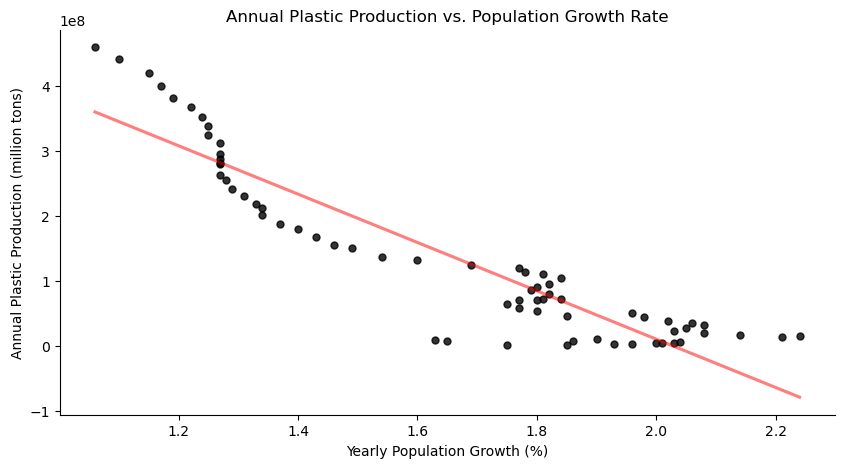

In [11]:
# First, we have to make sure that all our data is in the proper types
print(df.dtypes)

# We need to convert population to an int in order to graph
df['Population'] = df['Population'].astype(str).str.replace(',', '')
df['Population'] = df['Population'].astype(int)

# Might as well fix the others as well...
df['Yearly Population Growth(Numeric)'] = df['Yearly Population Growth(Numeric)'].astype(str).str.replace(',', '')
df['Yearly Population Growth(Numeric)'] = df['Yearly Population Growth(Numeric)'].astype(int)
df['Yearly Population Growth(%)'] = df['Yearly Population Growth(%)'].astype(str).str.rstrip('%').astype('float')

# Check for any NaNs
df['Population'].isna().sum() # good! there are no missing values


# Now, making the graph

# Scatter plot of plastic production vs population with a regression line
fig, ax = plt.subplots(figsize=(10,5))

sns.regplot(x = 'Yearly Population Growth(%)', y = 'Annual Plastic Production', data = df,
            ax = ax,
            color = 'black',
            ci = 0, # suppresses CI
            line_kws={"color": "red", 'alpha':0.5},
            scatter_kws={'s': 25}
           )

sns.despine(ax = ax)


ax.set_title('Annual Plastic Production vs. Population Growth Rate')
ax.set_ylabel('Annual Plastic Production (million tons)')
ax.set_xlabel('Yearly Population Growth (%)')
plt.show()

In [12]:
#We must load and merge these datasets
pop_india=pd.read_csv("SPPOPGROWIND.csv")
pop_usa=pd.read_csv("SPPOPGROWUSA-2.csv")
pop_china=pd.read_csv("SPPOPGROWCHN.csv")
#for each dataframe we must add a column "Entity": "China", "India", "United States"
pop_india["Entity"]="India"
pop_usa["Entity"]="United States"
pop_china["Entity"]="China"
#rename the SPPOPGROW column to population growth rate
pop_india.rename(columns={"SPPOPGROWIND":"Population Growth Rate"}, inplace=True)
pop_usa.rename(columns={"SPPOPGROWUSA":"Population Growth Rate"}, inplace=True)
pop_china.rename(columns={"SPPOPGROWCHN":"Population Growth Rate"}, inplace=True)
#We must format the observation date to only include the year under column "Year" as an int64
pop_india["Year"]=pop_india["observation_date"].str[:4].astype(int)
pop_usa["Year"]=pop_usa["observation_date"].str[:4].astype(int)
pop_china["Year"]=pop_china["observation_date"].str[:4].astype(int)
pop_india.drop(columns=["observation_date"], inplace=True)
pop_usa.drop(columns=["observation_date"], inplace=True)
pop_china.drop(columns=["observation_date"], inplace=True)
#Vertically merge all three dataframes for a single population growth df
population_growth_countrywise = pd.concat([pop_india, pop_usa, pop_china], ignore_index=True)
print(population_growth_countrywise.dtypes)

Population Growth Rate    float64
Entity                     object
Year                        int64
dtype: object


In [14]:
!ls

1- global-plastics-production.csv
2- share-of-global-plastic-waste-emitted-to-the-ocean.csv
4- mismanaged-plastic-waste-per-capita.csv
Final Project Notebook.ipynb
SPPOPGROWCHN.csv
SPPOPGROWIND.csv
SPPOPGROWUSA-2.csv
World Population Growth.csv
merged data.csv
plastic-pollution.zip
plastic_pollution_countrywise.csv
world-population-growth.zip


In [15]:
plastic_poll=pd.read_csv("plastic_pollution_countrywise.csv")
plastic_n_population = pd.merge(
    left=population_growth_countrywise,
    right=plastic_poll,
    how='inner',
    on=['Entity', 'Year']
)
plastic_n_population["Share of total pollutants from regional waste"]=plastic_n_population["Share of waste incinerated from total regional waste"]+plastic_n_population["Share of littered and mismanaged from total regional waste"]+plastic_n_population["Share of waste landfilled from total regional waste"]
print(plastic_n_population.head())
#plot different time series for each of the pollution types, with each country as a separate line on the graph.


   Population Growth Rate Entity  Year Code  \
0                1.879398  India  2000  IND   
1                1.870608  India  2001  IND   
2                1.811294  India  2002  IND   
3                1.734382  India  2003  IND   
4                1.703570  India  2004  IND   

   Share of waste recycled from total regional waste  \
0                                           5.072351   
1                                           5.518129   
2                                           5.967143   
3                                           6.414317   
4                                           6.862617   

   Share of waste incinerated from total regional waste  \
0                                           1.688645      
1                                           1.810416      
2                                           1.934149      
3                                           2.058212      
4                                           2.183653      

   Share of littered and 

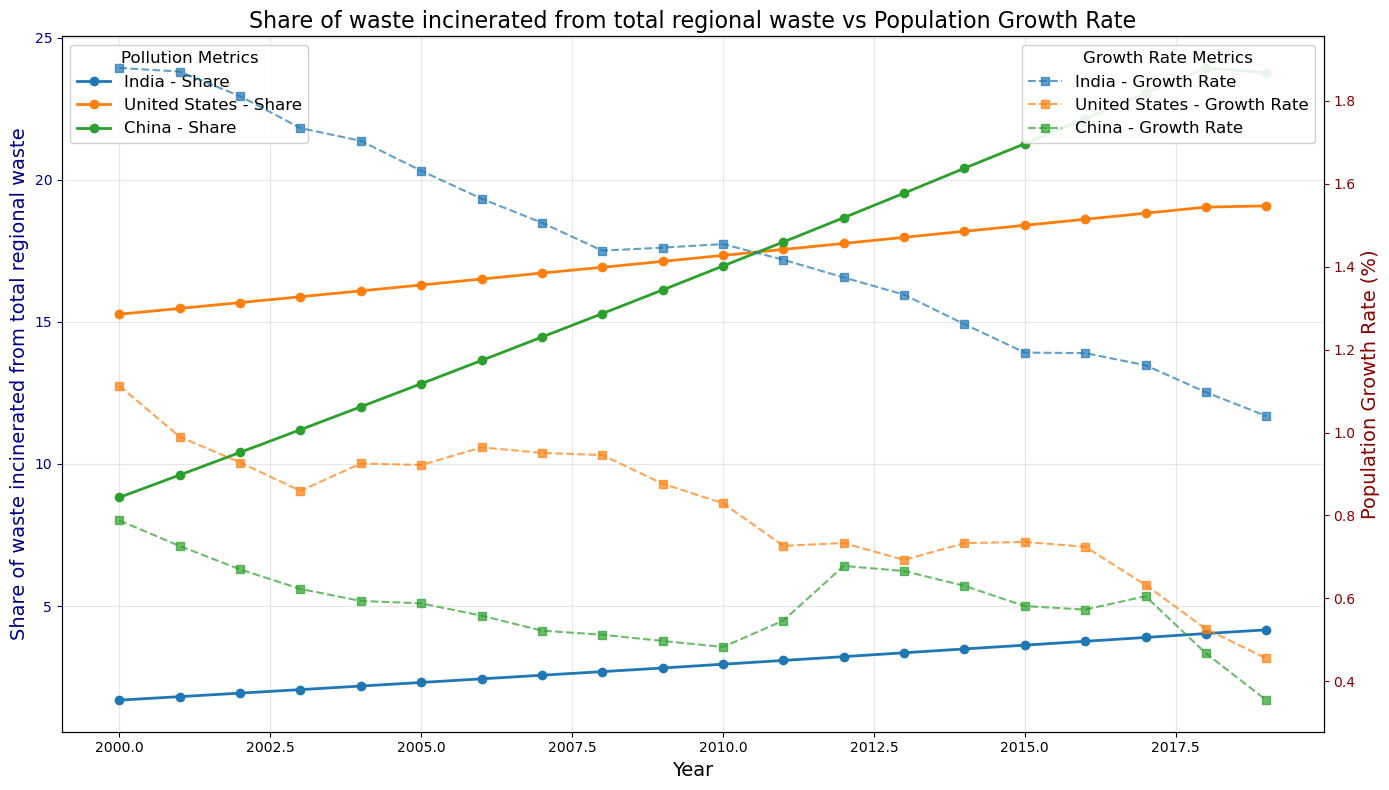

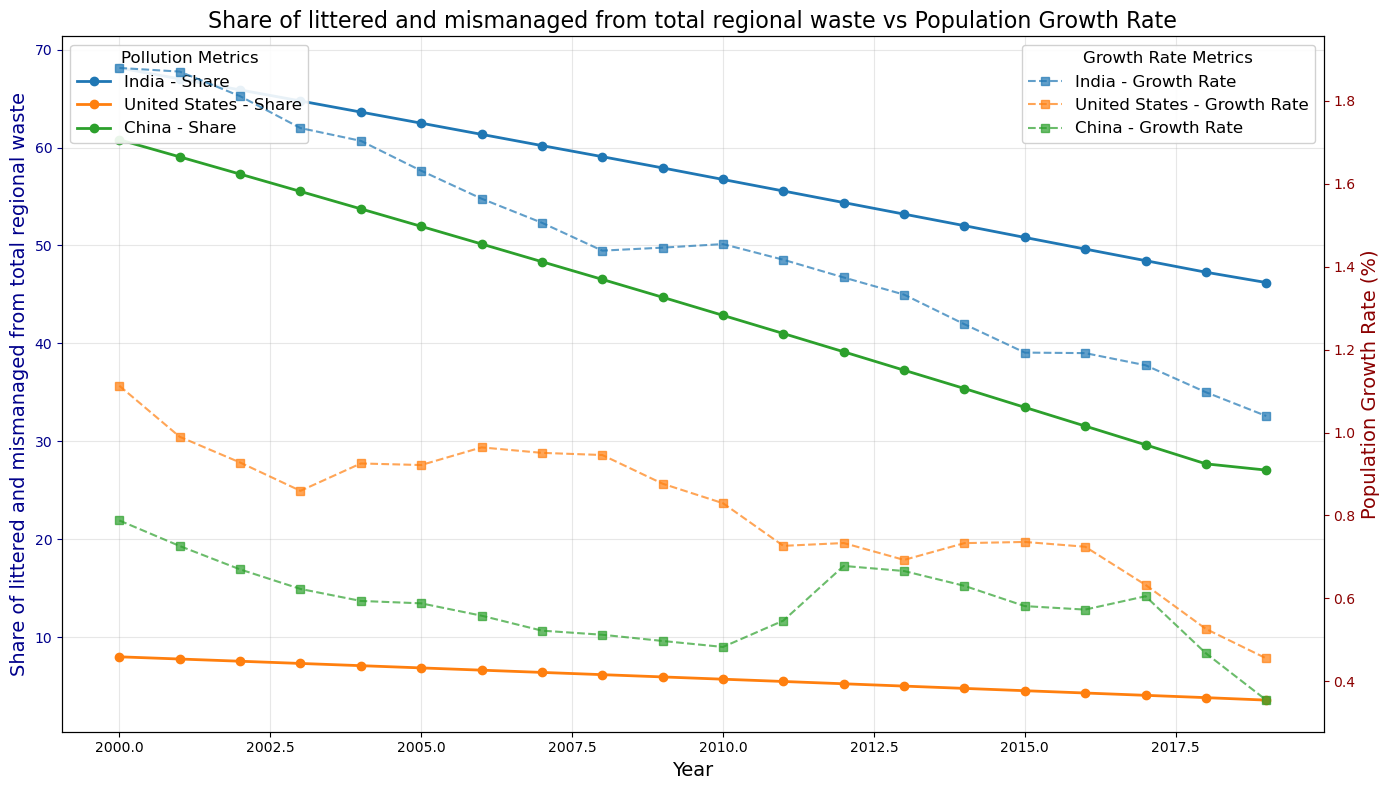

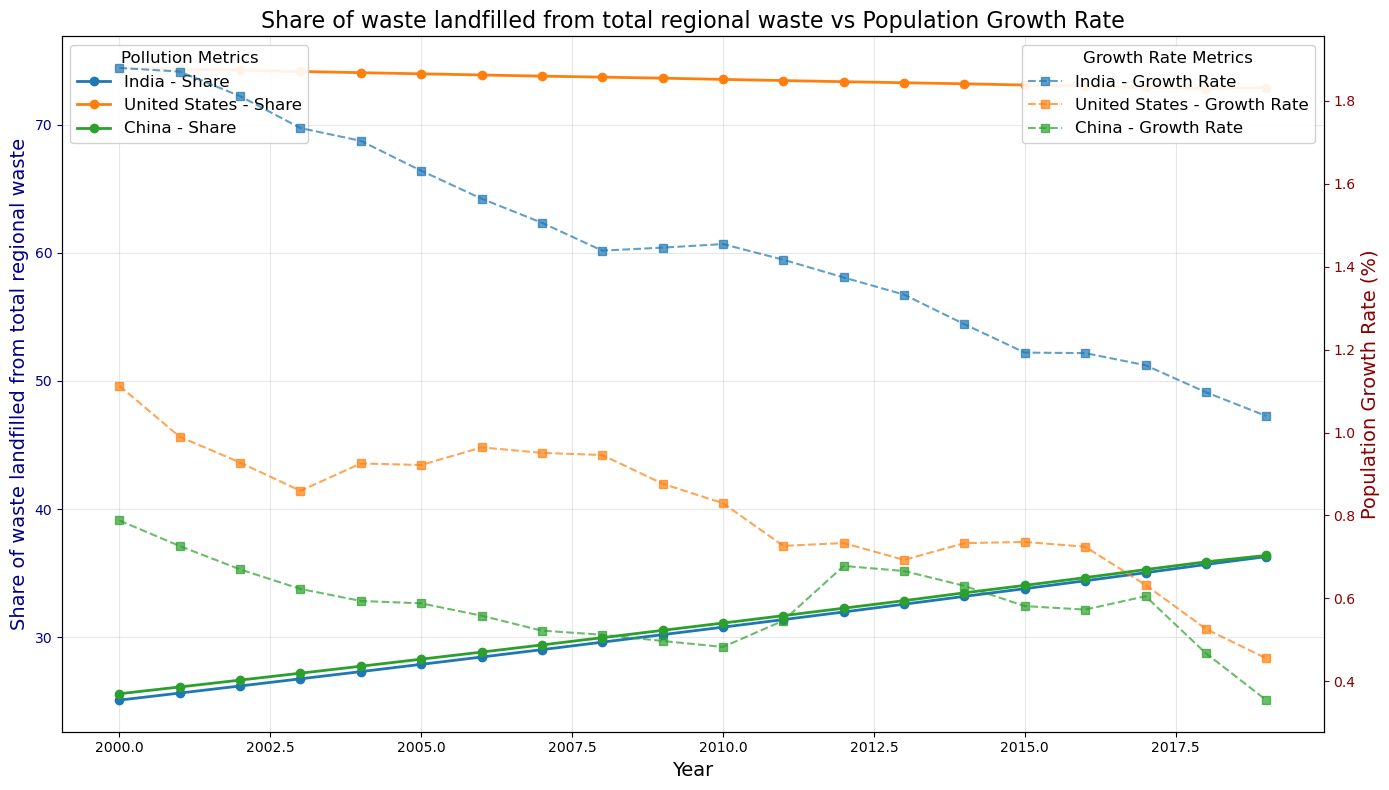

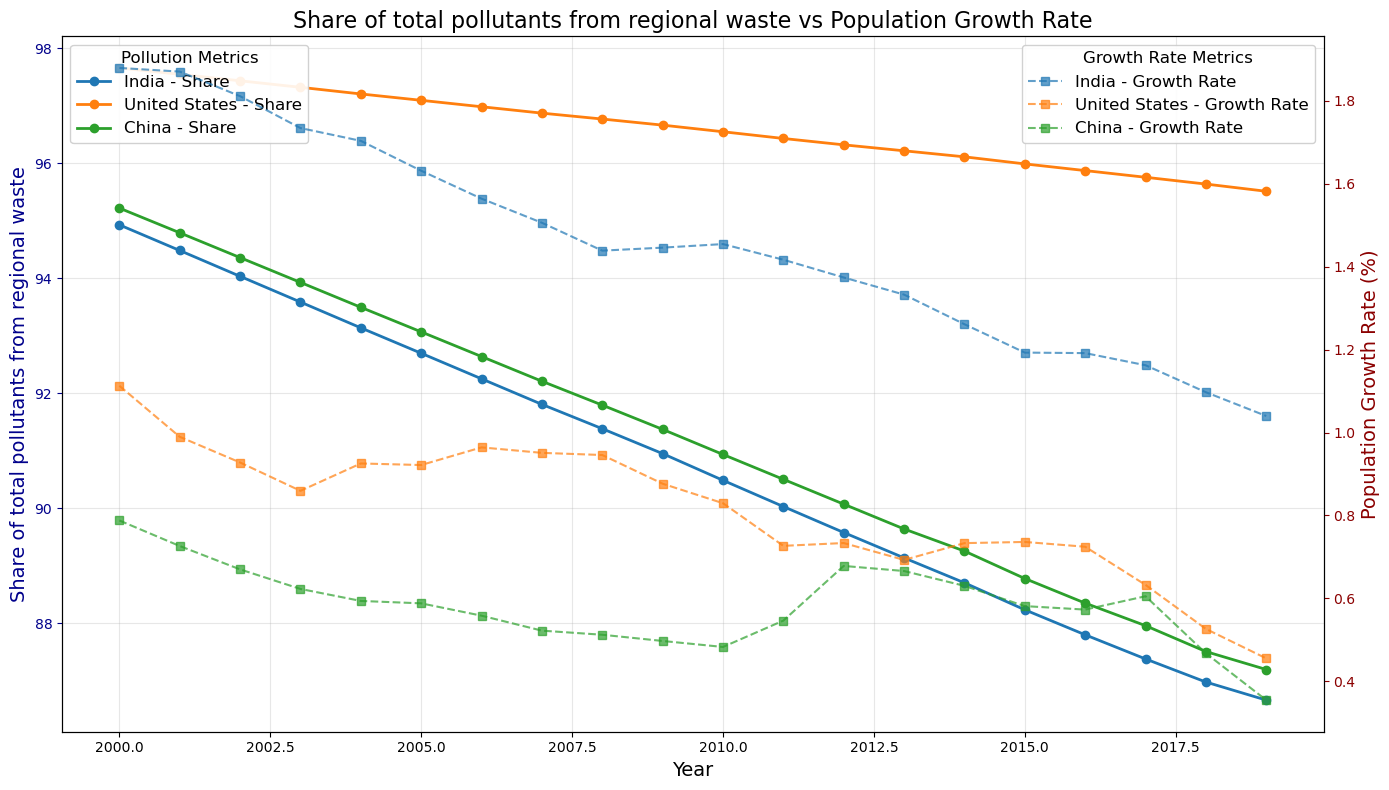

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def create_dual_axis_plot(df, pollution_metric, title):
    # Set up the figure and primary axis
    fig, ax1 = plt.subplots(figsize=(14, 8))

    # Define a color palette for countries
    countries = df['Entity'].unique()
    color_palette = sns.color_palette("tab10", len(countries))
    country_colors = dict(zip(countries, color_palette))

    # Plot pollution metric on the left y-axis
    for i, country in enumerate(countries):
        country_data = df[df['Entity'] == country].sort_values('Year')
        ax1.plot(
            country_data['Year'],
            country_data[pollution_metric],
            marker='o',
            linestyle='-',
            color=country_colors[country],
            label=f"{country} - {pollution_metric.split(' ')[0]}",
            linewidth=2
        )

    # Set up the secondary axis for population growth
    ax2 = ax1.twinx()

    # Plot population growth rate on the right y-axis with dashed lines
    for i, country in enumerate(countries):
        country_data = df[df['Entity'] == country].sort_values('Year')
        ax2.plot(
            country_data['Year'],
            country_data['Population Growth Rate'],  # Updated column name
            marker='s',  # Square markers to differentiate
            linestyle='--',  # Dashed line
            color=country_colors[country],
            label=f"{country} - Growth Rate",
            alpha=0.7,
            linewidth=1.5
        )

    # Add labels and title
    ax1.set_xlabel('Year', fontsize=14)
    ax1.set_ylabel(pollution_metric, fontsize=14, color='darkblue')
    ax2.set_ylabel('Population Growth Rate (%)', fontsize=14, color='darkred')
    plt.title(title, fontsize=16)

    # Adjust tick colors to match axis labels
    ax1.tick_params(axis='y', colors='darkblue')
    ax2.tick_params(axis='y', colors='darkred')

    # Add grid for better readability
    ax1.grid(True, alpha=0.3)

    # Create separate legends for each metric type
    pollution_handles = []
    pollution_labels = []
    growth_handles = []
    growth_labels = []

    # Get handles and labels from both axes
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()

    # Separate pollution and growth rate elements
    for handle, label in zip(handles1, labels1):
        pollution_handles.append(handle)
        pollution_labels.append(label)

    for handle, label in zip(handles2, labels2):
        growth_handles.append(handle)
        growth_labels.append(label)

    # Add pollution legend in the upper left
    ax1.legend(pollution_handles, pollution_labels, loc='upper left',
               fontsize=12, framealpha=0.9, title='Pollution Metrics',
               title_fontsize=12)

    # Add growth rate legend in the upper right
    ax2.legend(growth_handles, growth_labels, loc='upper right',
               fontsize=12, framealpha=0.9, title='Growth Rate Metrics',
               title_fontsize=12)

    plt.tight_layout()

    return fig

# Create dual-axis plots for each pollution metric
pollution_metrics = [
    'Share of waste incinerated from total regional waste',
    'Share of littered and mismanaged from total regional waste',
    'Share of waste landfilled from total regional waste',
    'Share of total pollutants from regional waste'
]

for metric in pollution_metrics:
    fig = create_dual_axis_plot(
        plastic_n_population,
        metric,
        f"{metric} vs Population Growth Rate"
    )
    plt.savefig(f"{metric.replace(' ', '_')}_dual_axis.png", dpi=300, bbox_inches='tight')
    plt.show()

/var/folders/mt/r884hw690sn26qjy_blnrh5c0000gn/T/ipykernel_5317/983191393.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ["Intercept", f"{model.params[0]:.4f}", f"{model.pvalues[0]:.4f}"],
/var/folders/mt/r884hw690sn26qjy_blnrh5c0000gn/T/ipykernel_5317/983191393.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ["Intercept", f"{model.params[0]:.4f}", f"{model.pvalues[0]:.4f}"],
/var/folders/mt/r884hw690sn26qjy_blnrh5c0000gn/T/ipykernel_5317/983191393.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consisten

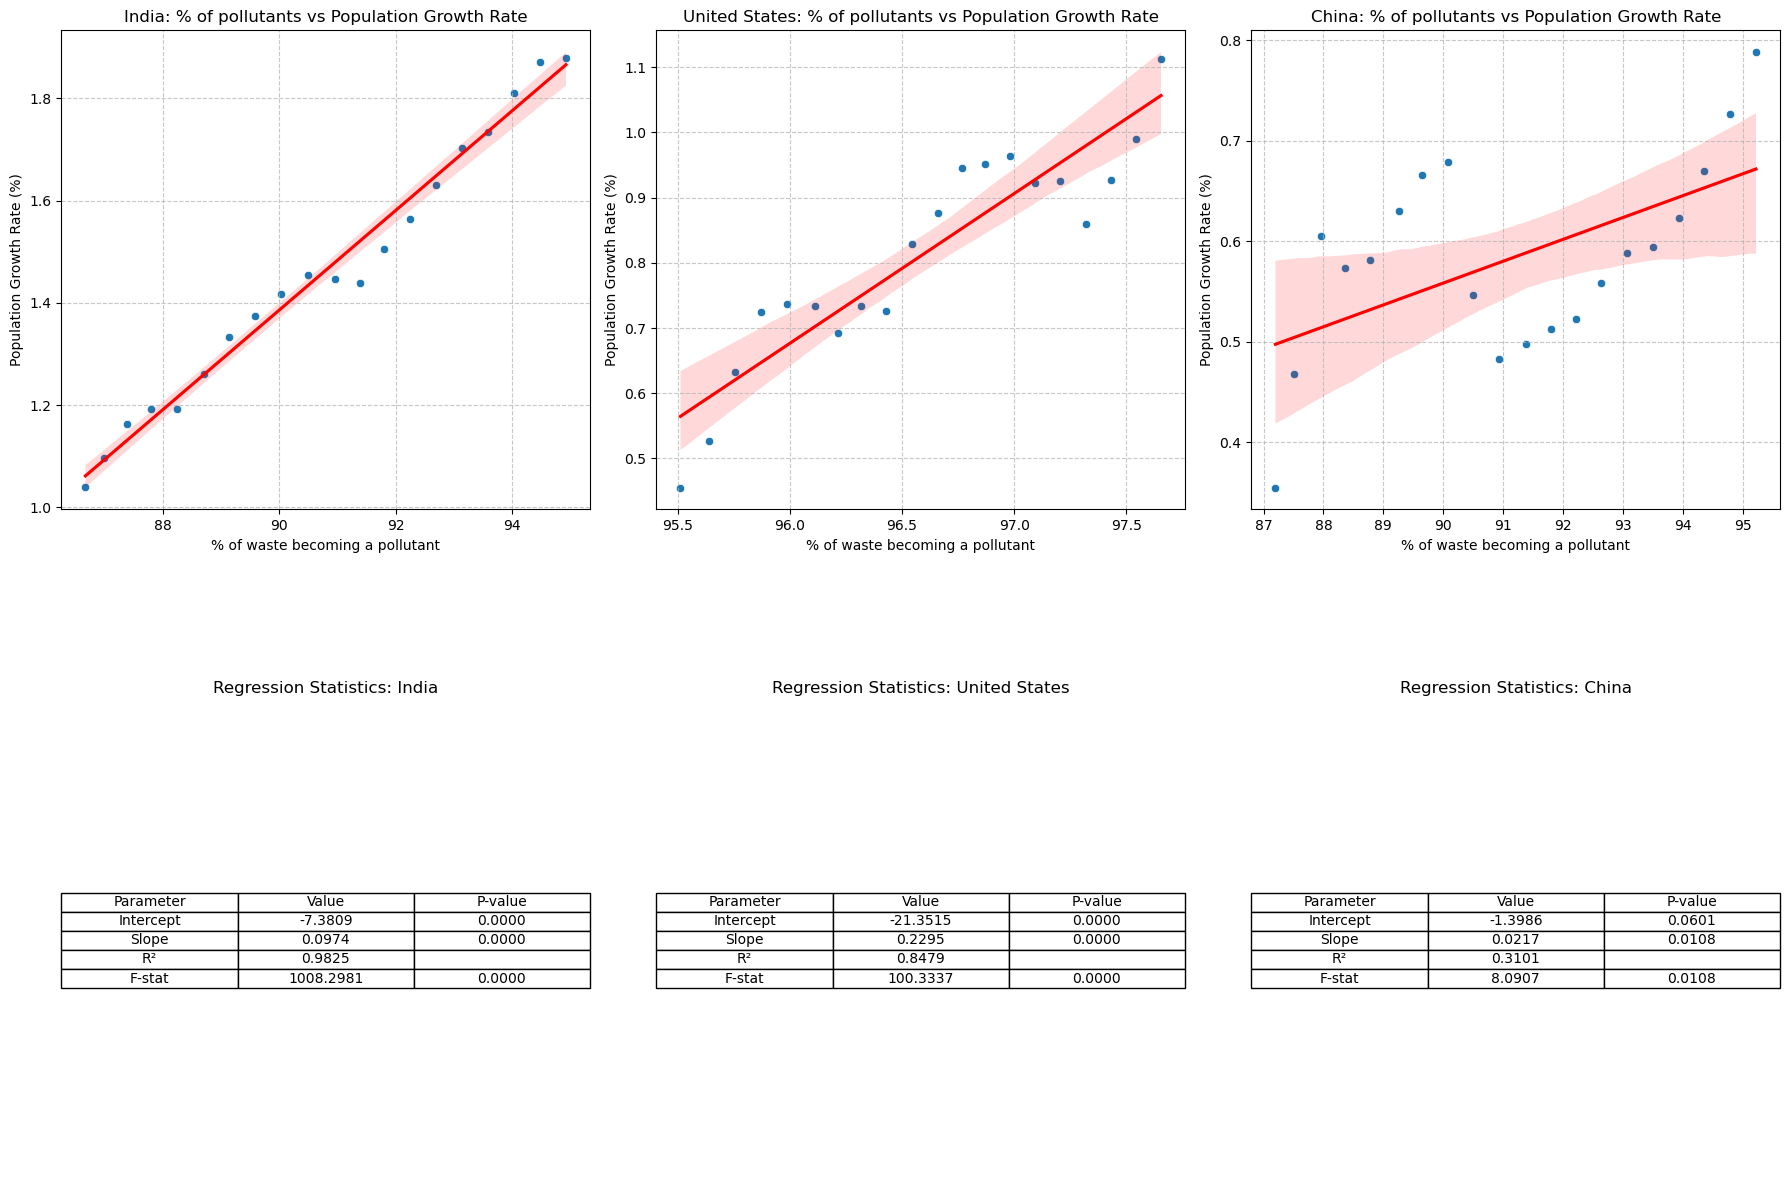

In [45]:
#Now we create 3 plots for each country of pollution as a % vs the population growth % on the y axis.
#We can also create other plots for different kinds of pollutants and see if any of them have a significant correlation with the population growth rate
plt.figure(figsize=(18, 12))  # Taller figure to fit both plots and tables

# Get the list of unique entities
entities = plastic_n_population['Entity'].unique()

# Create three subplots - first row for plots, second row for tables
for i, entity in enumerate(entities, 1):
    # Original scatter plot code (top row)
    plt.subplot(2, 3, i)

    # Filter data for the current entity
    entity_data = plastic_n_population[plastic_n_population['Entity'] == entity]

    # Create scatter plot
    sns.scatterplot(x='Share of total pollutants from regional waste', y='Population Growth Rate', data=entity_data)

    # Add trend line
    sns.regplot(x='Share of total pollutants from regional waste', y='Population Growth Rate', data=entity_data,
                scatter=False, line_kws={"color":"red"})

    # Set title and labels
    plt.title(f'{entity}: % of pollutants vs Population Growth Rate')
    plt.xlabel('% of waste becoming a pollutant')
    plt.ylabel('Population Growth Rate (%)')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Add regression table (bottom row)
    plt.subplot(2, 3, i+3)
    plt.axis('off')  # Turn off axes

    # Prepare regression data
    X = sm.add_constant(entity_data['Share of total pollutants from regional waste'])
    y = entity_data['Population Growth Rate']
    model = sm.OLS(y, X).fit()

    # Create regression table
    table_data = [
        ["Parameter", "Value", "P-value"],
        ["Intercept", f"{model.params[0]:.4f}", f"{model.pvalues[0]:.4f}"],
        ["Slope", f"{model.params[1]:.4f}", f"{model.pvalues[1]:.4f}"],
        ["R²", f"{model.rsquared:.4f}", ""],
        ["F-stat", f"{model.fvalue:.4f}", f"{model.f_pvalue:.4f}"]
    ]

    plt.table(cellText=table_data, loc='center', cellLoc='center')
    plt.title(f'Regression Statistics: {entity}')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.4)

/var/folders/mt/r884hw690sn26qjy_blnrh5c0000gn/T/ipykernel_5317/1360651797.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ["Intercept", f"{model.params[0]:.4f}", f"{model.pvalues[0]:.4f}"],
/var/folders/mt/r884hw690sn26qjy_blnrh5c0000gn/T/ipykernel_5317/1360651797.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ["Intercept", f"{model.params[0]:.4f}", f"{model.pvalues[0]:.4f}"],
/var/folders/mt/r884hw690sn26qjy_blnrh5c0000gn/T/ipykernel_5317/1360651797.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consis

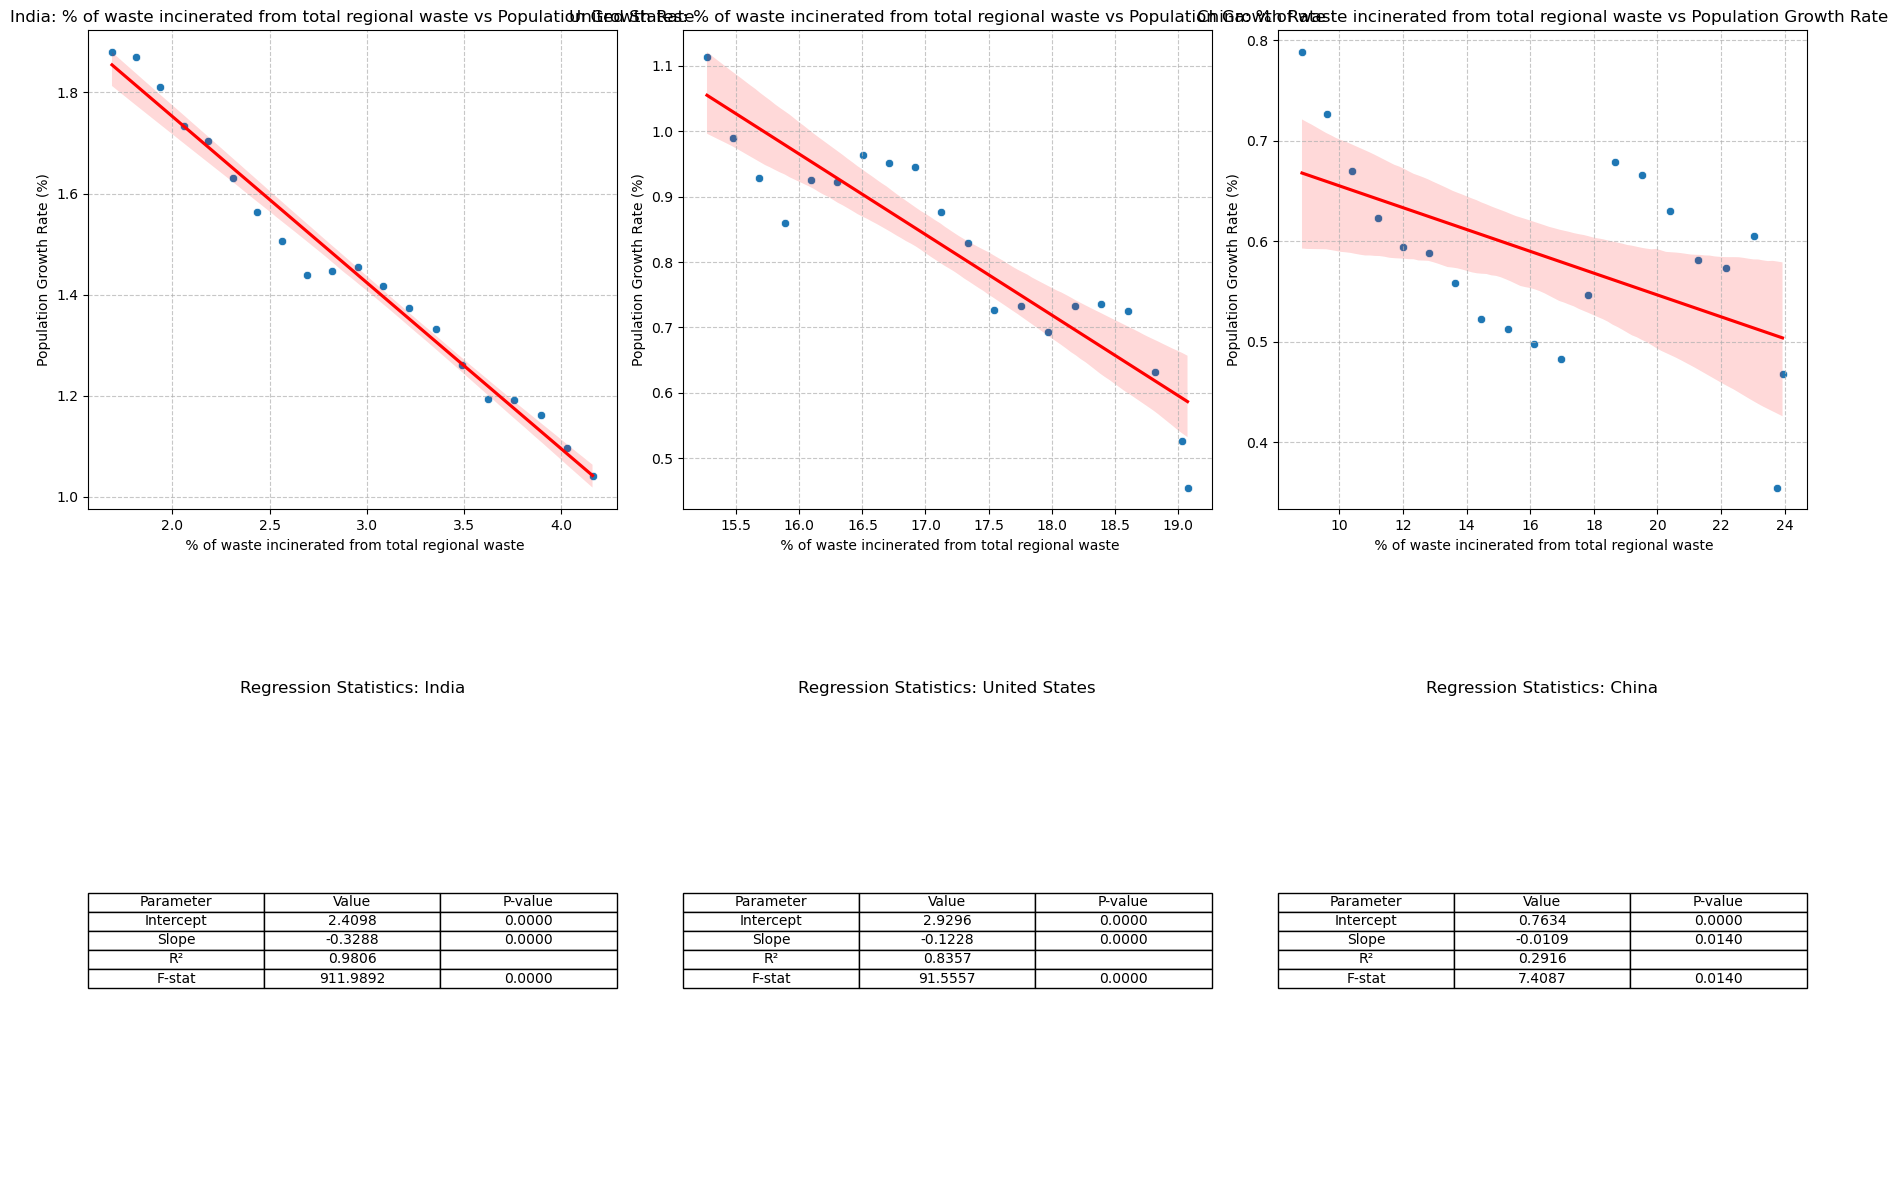

In [47]:
######
#Now we create 3 plots for each country of pollution as a % vs the population growth % on the y axis.
#We can also create other plots for different kinds of pollutants and see if any of them have a significant correlation with the population growth rate
plt.figure(figsize=(18, 12))  # Taller figure to fit both plots and tables

# Get the list of unique entities
entities = plastic_n_population['Entity'].unique()

# Create three subplots - first row for plots, second row for tables
for i, entity in enumerate(entities, 1):
    # Original scatter plot code (top row)
    plt.subplot(2, 3, i)

    # Filter data for the current entity
    entity_data = plastic_n_population[plastic_n_population['Entity'] == entity]

    # Create scatter plot
    sns.scatterplot(x='Share of waste incinerated from total regional waste', y='Population Growth Rate', data=entity_data)

    # Add trend line
    sns.regplot(x='Share of waste incinerated from total regional waste', y='Population Growth Rate', data=entity_data,
                scatter=False, line_kws={"color":"red"})

    # Set title and labels
    plt.title(f'{entity}: % of waste incinerated from total regional waste vs Population Growth Rate')
    plt.xlabel(' % of waste incinerated from total regional waste')
    plt.ylabel('Population Growth Rate (%)')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Add regression table (bottom row)
    plt.subplot(2, 3, i+3)
    plt.axis('off')  # Turn off axes

    # Prepare regression data
    X = sm.add_constant(entity_data['Share of waste incinerated from total regional waste'])
    y = entity_data['Population Growth Rate']
    model = sm.OLS(y, X).fit()

    # Create regression table
    table_data = [
        ["Parameter", "Value", "P-value"],
        ["Intercept", f"{model.params[0]:.4f}", f"{model.pvalues[0]:.4f}"],
        ["Slope", f"{model.params[1]:.4f}", f"{model.pvalues[1]:.4f}"],
        ["R²", f"{model.rsquared:.4f}", ""],
        ["F-stat", f"{model.fvalue:.4f}", f"{model.f_pvalue:.4f}"]
    ]

    plt.table(cellText=table_data, loc='center', cellLoc='center')
    plt.title(f'Regression Statistics: {entity}')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.4)

/var/folders/mt/r884hw690sn26qjy_blnrh5c0000gn/T/ipykernel_5317/2258266298.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ["Intercept", f"{model.params[0]:.4f}", f"{model.pvalues[0]:.4f}"],
/var/folders/mt/r884hw690sn26qjy_blnrh5c0000gn/T/ipykernel_5317/2258266298.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ["Intercept", f"{model.params[0]:.4f}", f"{model.pvalues[0]:.4f}"],
/var/folders/mt/r884hw690sn26qjy_blnrh5c0000gn/T/ipykernel_5317/2258266298.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consis

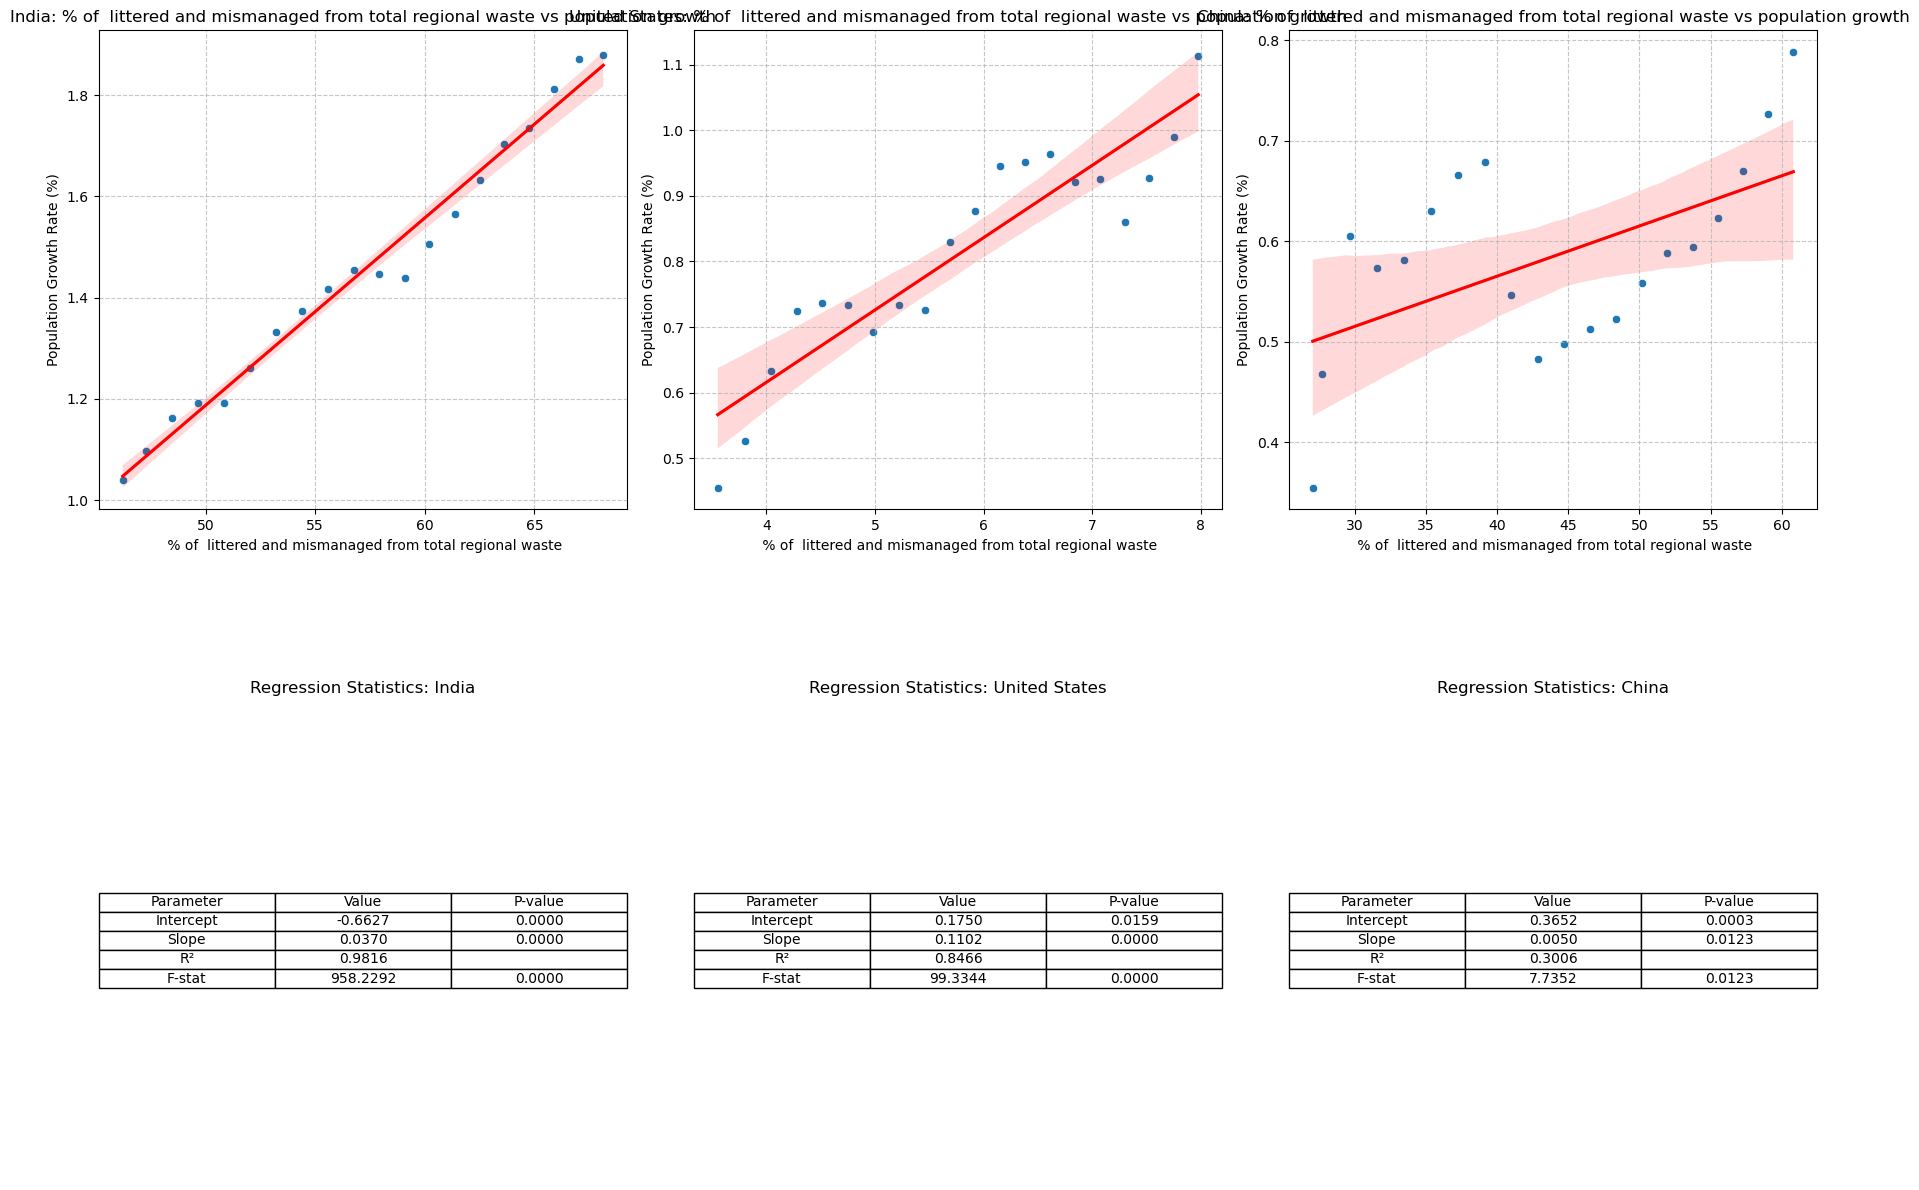

In [49]:
######
#Now we create 3 plots for each country of pollution as a % vs the population growth % on the y axis.
#We can also create other plots for different kinds of pollutants and see if any of them have a significant correlation with the population growth rate
plt.figure(figsize=(18, 12))  # Taller figure to fit both plots and tables

# Get the list of unique entities
entities = plastic_n_population['Entity'].unique()

# Create three subplots - first row for plots, second row for tables
for i, entity in enumerate(entities, 1):
    # Original scatter plot code (top row)
    plt.subplot(2, 3, i)

    # Filter data for the current entity
    entity_data = plastic_n_population[plastic_n_population['Entity'] == entity]

    # Create scatter plot
    sns.scatterplot(x='Share of littered and mismanaged from total regional waste', y='Population Growth Rate', data=entity_data)

    # Add trend line
    sns.regplot(x='Share of littered and mismanaged from total regional waste', y='Population Growth Rate', data=entity_data,
                scatter=False, line_kws={"color":"red"})

    # Set title and labels
    plt.title(f'{entity}: % of  littered and mismanaged from total regional waste vs population growth')
    plt.xlabel(' % of  littered and mismanaged from total regional waste')
    plt.ylabel('Population Growth Rate (%)')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Add regression table (bottom row)
    plt.subplot(2, 3, i+3)
    plt.axis('off')  # Turn off axes

    # Prepare regression data
    X = sm.add_constant(entity_data['Share of littered and mismanaged from total regional waste'])
    y = entity_data['Population Growth Rate']
    model = sm.OLS(y, X).fit()

    # Create regression table
    table_data = [
        ["Parameter", "Value", "P-value"],
        ["Intercept", f"{model.params[0]:.4f}", f"{model.pvalues[0]:.4f}"],
        ["Slope", f"{model.params[1]:.4f}", f"{model.pvalues[1]:.4f}"],
        ["R²", f"{model.rsquared:.4f}", ""],
        ["F-stat", f"{model.fvalue:.4f}", f"{model.f_pvalue:.4f}"]
    ]

    plt.table(cellText=table_data, loc='center', cellLoc='center')
    plt.title(f'Regression Statistics: {entity}')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.4)

/var/folders/mt/r884hw690sn26qjy_blnrh5c0000gn/T/ipykernel_5317/3786949029.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ["Intercept", f"{model.params[0]:.4f}", f"{model.pvalues[0]:.4f}"],
/var/folders/mt/r884hw690sn26qjy_blnrh5c0000gn/T/ipykernel_5317/3786949029.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ["Intercept", f"{model.params[0]:.4f}", f"{model.pvalues[0]:.4f}"],
/var/folders/mt/r884hw690sn26qjy_blnrh5c0000gn/T/ipykernel_5317/3786949029.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consis

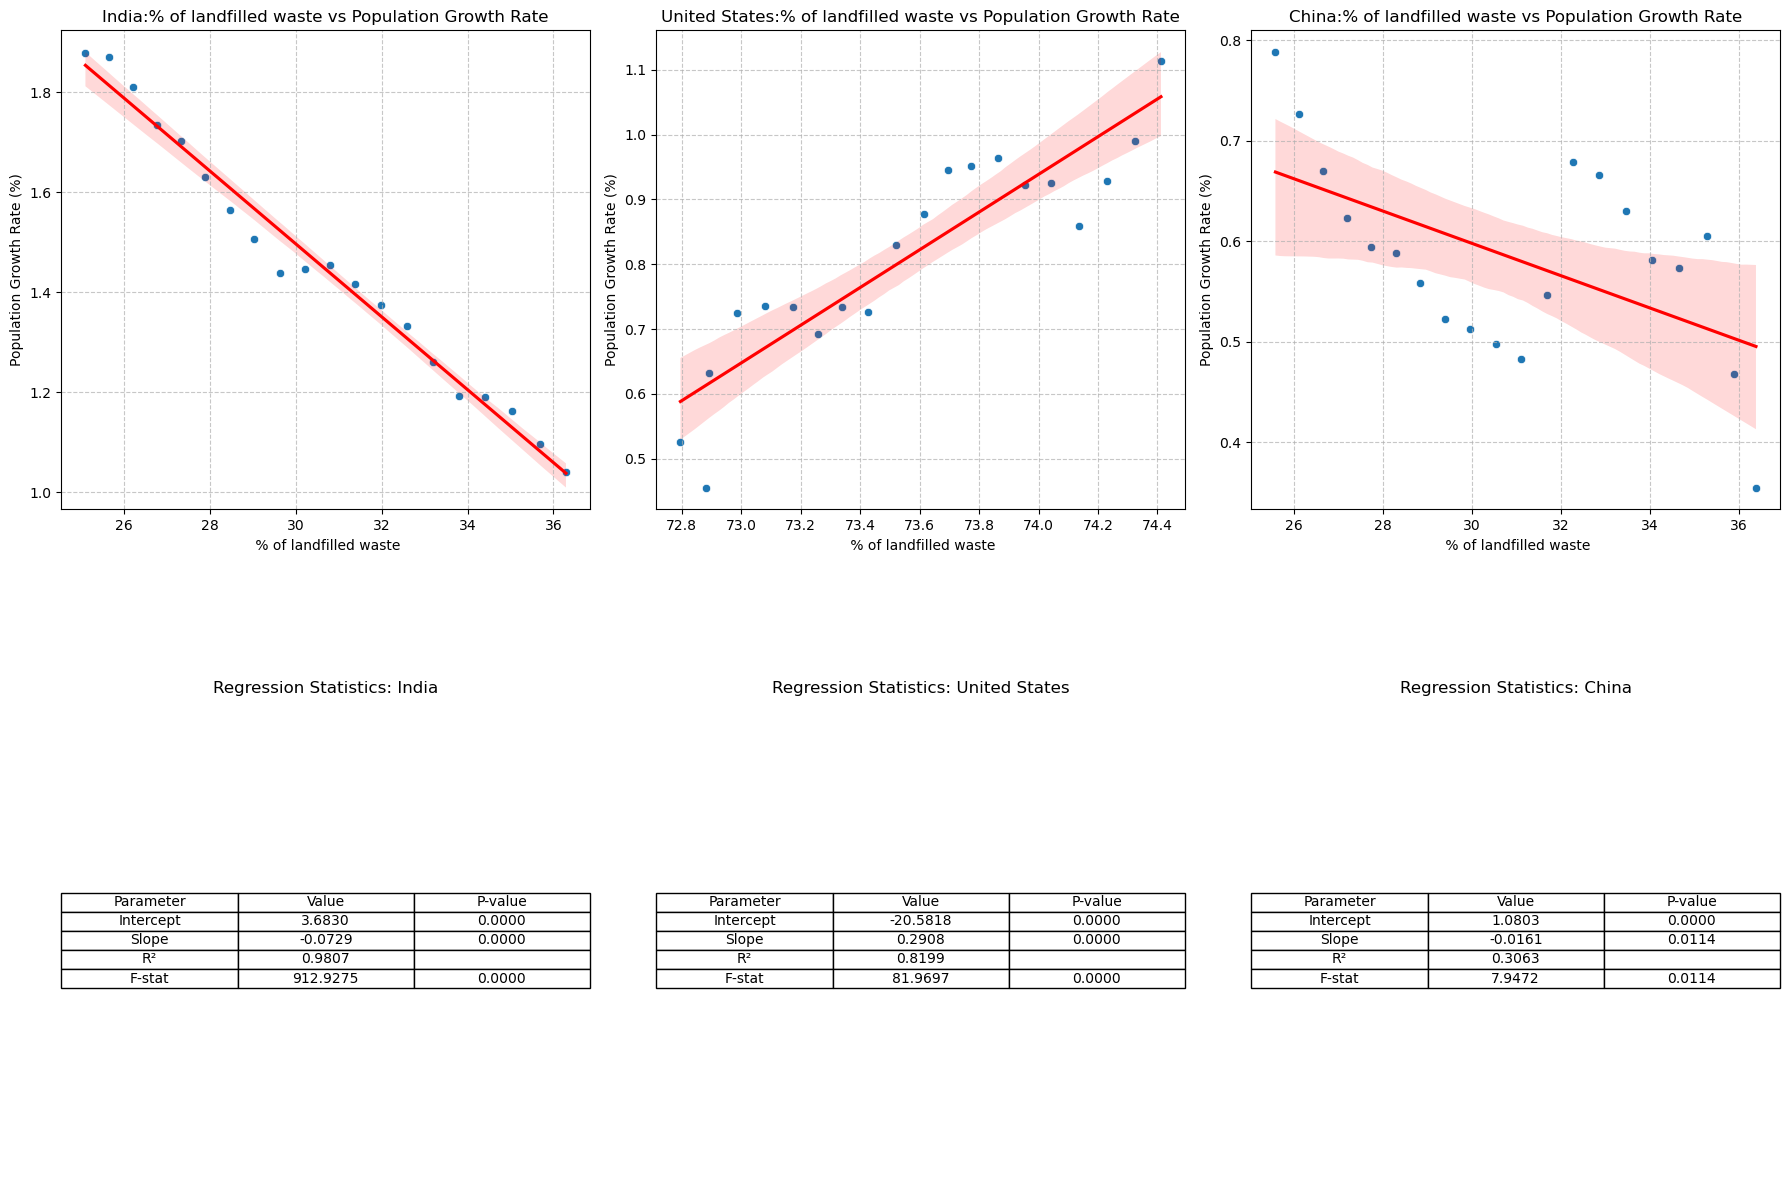

In [53]:

#####
plt.figure(figsize=(18, 12))  # Taller figure to fit both plots and tables

# Get the list of unique entities
entities = plastic_n_population['Entity'].unique()

# Create three subplots - first row for plots, second row for tables
for i, entity in enumerate(entities, 1):
    # Original scatter plot code (top row)
    plt.subplot(2, 3, i)

    # Filter data for the current entity
    entity_data = plastic_n_population[plastic_n_population['Entity'] == entity]

    # Create scatter plot
    sns.scatterplot(x='Share of waste landfilled from total regional waste', y='Population Growth Rate', data=entity_data)

    # Add trend line
    sns.regplot(x='Share of waste landfilled from total regional waste', y='Population Growth Rate', data=entity_data,
                scatter=False, line_kws={"color":"red"})

    # Set title and labels
    plt.title(f'{entity}:% of landfilled waste vs Population Growth Rate')
    plt.xlabel(' % of landfilled waste')
    plt.ylabel('Population Growth Rate (%)')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Add regression table (bottom row)
    plt.subplot(2, 3, i+3)
    plt.axis('off')  # Turn off axes

    # Prepare regression data
    X = sm.add_constant(entity_data['Share of waste landfilled from total regional waste'])
    y = entity_data['Population Growth Rate']
    model = sm.OLS(y, X).fit()

    # Create regression table
    table_data = [
        ["Parameter", "Value", "P-value"],
        ["Intercept", f"{model.params[0]:.4f}", f"{model.pvalues[0]:.4f}"],
        ["Slope", f"{model.params[1]:.4f}", f"{model.pvalues[1]:.4f}"],
        ["R²", f"{model.rsquared:.4f}", ""],
        ["F-stat", f"{model.fvalue:.4f}", f"{model.f_pvalue:.4f}"]
    ]

    plt.table(cellText=table_data, loc='center', cellLoc='center')
    plt.title(f'Regression Statistics: {entity}')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.4)